# Process Automation Assistant — Sensor/Log Anomaly Agent

**A LangGraph + Gemini agent that watches industrial, building-automation, and traffic-management sensor streams, detects anomalies, grounds its reasoning in a maintenance knowledge base (RAG), and recommends concrete actions.**

Built as a portfolio project targeting the kind of work described in evon's *Software Development & AI* internship posting (St. Ruprecht an der Raab, Austria) — evon's [XAMControl](https://evon-automation.com/) platform is used in **industry**, **traffic management**, and **building automation (GLT)**, so this notebook simulates sensor/log data across all three domains and builds an assistance system on top of it.

**Pipeline:**

```
sensor/log stream → anomaly detection → RAG retrieval (maintenance KB) → LLM reasoning (Gemini) → recommended action → structured log
```

**Stack:** Google Colab · `google-genai` (Gemini) · LangGraph · FAISS · sentence-transformers · Gradio · scikit-learn

> Run all cells top to bottom. You'll need a free [Gemini API key](https://aistudio.google.com/apikey) for the reasoning step — everything else (data generation, anomaly detection, retrieval, dashboard) runs with no key.


## 0. Setup

In [1]:
# Install dependencies (Colab-friendly)
!pip install -q google-genai langgraph faiss-cpu sentence-transformers gradio scikit-learn pandas numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 20.9 MB/s eta 0:00:00


In [2]:
import os, json, time, textwrap, random
from getpass import getpass
from dataclasses import dataclass, field
from typing import TypedDict, List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

import faiss
from sentence_transformers import SentenceTransformer

from langgraph.graph import StateGraph, END

from google import genai

# --- Gemini API key ---------------------------------------------------------
# In Colab: Runtime > add a secret named GEMINI_API_KEY (recommended), or paste when prompted.
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("Gemini_API_Key")
except Exception:
    GEMINI_API_KEY = None

if not GEMINI_API_KEY:
    GEMINI_API_KEY = os.environ.get("Gemini_API_Key") or getpass("Enter your Gemini API key: ")

client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = "gemini-2.5-flash"  # swap to gemini-2.5-pro for higher-quality reasoning

random.seed(7)
np.random.seed(7)


## 1. Synthetic multi-domain sensor data

Three domains mirroring evon's application areas, each with a normal operating band and a handful of injectable anomaly types.

| Domain | Signals | Example anomalies |
|---|---|---|
| **Industry** | motor vibration (mm/s), bearing temp (°C), current draw (A) | bearing wear (rising vibration), overheating, power surge |
| **Building automation (GLT)** | zone temp (°C), CO2 (ppm), HVAC energy (kW) | stuck damper (temp drift), ventilation failure (CO2 spike), energy waste (kW spike at night) |
| **Traffic management** | intersection flow (veh/min), avg speed (km/h), queue length (m) | sensor dropout, signal-timing congestion, incident (sudden stop) |


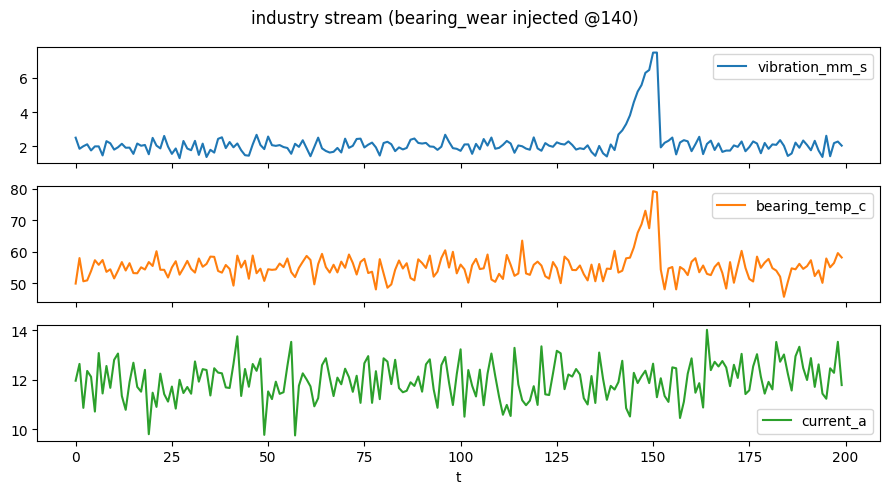

,t,vibration_mm_s,bearing_temp_c,current_a
195,195,2.619139,57.918678,11.223707
196,196,1.426775,55.115254,12.453156
197,197,2.190924,56.469466,12.270344
198,198,2.281656,59.627449,13.523445
199,199,2.044120,58.238638,11.775914


In [3]:
DOMAIN_CONFIG = {
    "industry": {
        "signals": {
            "vibration_mm_s": (2.0, 0.3),      # (mean, std) normal operation
            "bearing_temp_c": (55.0, 3.0),
            "current_a": (12.0, 0.8),
        },
        "anomalies": {
            "bearing_wear": {"vibration_mm_s": +6.0, "bearing_temp_c": +18.0},
            "overheating":  {"bearing_temp_c": +30.0},
            "power_surge":  {"current_a": +9.0},
        },
    },
    "building": {
        "signals": {
            "zone_temp_c": (22.0, 0.5),
            "co2_ppm": (600.0, 40.0),
            "hvac_energy_kw": (8.0, 1.0),
        },
        "anomalies": {
            "stuck_damper":        {"zone_temp_c": +6.0},
            "ventilation_failure": {"co2_ppm": +1400.0},
            "energy_waste":        {"hvac_energy_kw": +14.0},
        },
    },
    "traffic": {
        "signals": {
            "flow_veh_min": (40.0, 6.0),
            "avg_speed_kmh": (48.0, 5.0),
            "queue_length_m": (30.0, 8.0),
        },
        "anomalies": {
            "sensor_dropout": {"flow_veh_min": -40.0},
            "congestion":     {"avg_speed_kmh": -30.0, "queue_length_m": +90.0},
            "incident":       {"avg_speed_kmh": -40.0, "flow_veh_min": -25.0},
        },
    },
}

def generate_stream(domain: str, n_points: int = 200, anomaly_at: Optional[int] = None,
                     anomaly_type: Optional[str] = None, anomaly_width: int = 12) -> pd.DataFrame:
    '''Generate a synthetic sensor stream for one domain, optionally injecting one anomaly window.'''
    cfg = DOMAIN_CONFIG[domain]
    data = {sig: np.random.normal(mean, std, n_points) for sig, (mean, std) in cfg["signals"].items()}

    if anomaly_at is not None and anomaly_type is not None:
        shifts = cfg["anomalies"][anomaly_type]
        end = min(n_points, anomaly_at + anomaly_width)
        ramp = np.linspace(0, 1, end - anomaly_at)
        for sig, shift in shifts.items():
            data[sig][anomaly_at:end] += shift * ramp

    df = pd.DataFrame(data)
    df.insert(0, "t", range(n_points))
    df.attrs["domain"] = domain
    df.attrs["injected_anomaly"] = anomaly_type
    df.attrs["injected_at"] = anomaly_at
    return df

# quick look
demo_df = generate_stream("industry", n_points=200, anomaly_at=140, anomaly_type="bearing_wear")
demo_df.plot(x="t", subplots=True, figsize=(9, 5), title="industry stream (bearing_wear injected @140)")
plt.tight_layout(); plt.show()
demo_df.tail()


## 2. Anomaly detection layer

A rolling z-score flags per-signal deviations; an `IsolationForest` catches multivariate anomalies the z-score misses (e.g. combinations of signals drifting together but each within its own normal range).


In [4]:
def detect_anomalies(df: pd.DataFrame, z_thresh: float = 3.0, contamination: float = 0.05) -> pd.DataFrame:
    signal_cols = [c for c in df.columns if c != "t"]
    result = df.copy()

    # rolling z-score per signal
    for col in signal_cols:
        roll_mean = df[col].rolling(30, min_periods=10).mean()
        roll_std = df[col].rolling(30, min_periods=10).std().replace(0, np.nan)
        z = (df[col] - roll_mean) / roll_std
        result[f"{col}_z"] = z.fillna(0)

    z_cols = [f"{c}_z" for c in signal_cols]
    result["zscore_flag"] = (result[z_cols].abs() > z_thresh).any(axis=1)

    # multivariate check
    iso = IsolationForest(contamination=contamination, random_state=7)
    result["iso_flag"] = iso.fit_predict(df[signal_cols]) == -1

    result["anomaly"] = result["zscore_flag"] | result["iso_flag"]
    return result

def summarize_anomaly_window(flagged_df: pd.DataFrame, domain: str, window: int = 5) -> Optional[Dict[str, Any]]:
    '''Turn the first flagged anomaly window into a compact event dict for the agent.'''
    hits = flagged_df[flagged_df["anomaly"]]
    if hits.empty:
        return None
    idx = hits.index[0]
    lo, hi = max(0, idx - window), min(len(flagged_df), idx + window)
    signal_cols = [c for c in DOMAIN_CONFIG[domain]["signals"]]
    before = flagged_df[signal_cols].iloc[max(0, lo - 20):lo].mean()
    during = flagged_df[signal_cols].iloc[lo:hi].mean()
    deltas = (during - before).round(2)
    return {
        "domain": domain,
        "t_index": int(idx),
        "signals_before": before.round(2).to_dict(),
        "signals_during": during.round(2).to_dict(),
        "deltas": deltas.to_dict(),
    }

flagged = detect_anomalies(demo_df)
event = summarize_anomaly_window(flagged, "industry")
event


{'domain': 'industry',
 't_index': 19,
 'signals_before': {'vibration_mm_s': 2.0,
  'bearing_temp_c': 54.21,
  'current_a': 11.95},
 'signals_during': {'vibration_mm_s': 2.04,
  'bearing_temp_c': 55.37,
  'current_a': 11.6},
 'deltas': {'vibration_mm_s': 0.03,
  'bearing_temp_c': 1.16,
  'current_a': -0.35}}

## 3. Domain knowledge base (RAG)

Short synthetic maintenance/operations notes per domain, embedded with `all-MiniLM-L6-v2` and indexed in FAISS — the agent retrieves the most relevant notes for the anomaly it just detected before asking Gemini to reason about it.


In [5]:
KNOWLEDGE_BASE = {
    "industry": [
        "Rising vibration combined with a slow bearing-temperature increase over minutes typically indicates bearing wear or lubrication loss. Recommended action: schedule inspection within 24h, reduce load if possible, check lubrication level.",
        "A sudden bearing-temperature spike with stable vibration suggests a cooling or lubrication failure rather than mechanical wear. Recommended action: stop the motor if temp exceeds safety threshold, inspect cooling system immediately.",
        "Current draw spikes without vibration or temperature change usually point to an electrical issue (voltage fluctuation, phase imbalance) rather than a mechanical fault. Recommended action: check upstream power supply and motor controller logs.",
        "Routine maintenance interval for industrial motors under evon XAMControl monitoring is every 2000 operating hours; deviations from baseline vibration of more than 3x standard deviation should trigger an early inspection.",
    ],
    "building": [
        "A sustained zone temperature rise with stable CO2 and energy readings usually indicates a stuck or miscalibrated damper. Recommended action: check damper actuator position, recalibrate BMS setpoint.",
        "A sharp CO2 spike with temperature roughly stable indicates a ventilation or air-handling unit failure. Recommended action: verify AHU fan status and fresh-air intake, notify facility staff if occupancy is high.",
        "HVAC energy draw rising outside occupied hours without a corresponding temperature demand suggests a scheduling fault or a unit stuck in an active mode. Recommended action: check BMS schedule configuration and override.",
        "Building automation (GLT) systems should flag any zone deviating more than 4°C from setpoint for more than 15 minutes as requiring facility technician review.",
    ],
    "traffic": [
        "A sudden drop in reported flow with speed and queue readings unaffected likely indicates a sensor or loop-detector dropout rather than an actual traffic change. Recommended action: flag sensor for diagnostic check, cross-reference with adjacent sensors.",
        "Falling average speed together with rising queue length indicates congestion; if gradual, it is likely signal-timing related. Recommended action: consider adaptive signal-timing adjustment for the affected approach.",
        "A sharp, simultaneous drop in speed and flow (rather than gradual) is characteristic of an incident (collision, stall, obstruction). Recommended action: alert traffic management center, prioritize the intersection for camera review.",
        "Traffic management deployments should distinguish gradual congestion trends from abrupt incident-like drops, since the required response differs (signal retiming vs. emergency dispatch).",
    ],
}

embedder = SentenceTransformer("all-MiniLM-L6-v2")

def build_faiss_index(domain: str):
    docs = KNOWLEDGE_BASE[domain]
    vecs = embedder.encode(docs, normalize_embeddings=True)
    index = faiss.IndexFlatIP(vecs.shape[1])
    index.add(np.array(vecs, dtype="float32"))
    return index, docs

DOMAIN_INDEXES = {d: build_faiss_index(d) for d in KNOWLEDGE_BASE}

def retrieve_context(domain: str, query: str, k: int = 2) -> List[str]:
    index, docs = DOMAIN_INDEXES[domain]
    qvec = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = index.search(np.array(qvec, dtype="float32"), k)
    return [docs[i] for i in idxs[0] if i != -1]

retrieve_context("industry", "vibration rising and bearing temperature increasing")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

['Rising vibration combined with a slow bearing-temperature increase over minutes typically indicates bearing wear or lubrication loss. Recommended action: schedule inspection within 24h, reduce load if possible, check lubrication level.',
 'A sudden bearing-temperature spike with stable vibration suggests a cooling or lubrication failure rather than mechanical wear. Recommended action: stop the motor if temp exceeds safety threshold, inspect cooling system immediately.']

## 4. LangGraph agent

`monitor → detect_anomaly → retrieve_context → reason_with_gemini → recommend_action → log`

Each node updates a shared `AgentState`; the graph is compiled once and re-run per incoming stream.


In [6]:
class AgentState(TypedDict, total=False):
    domain: str
    stream: pd.DataFrame
    flagged: pd.DataFrame
    event: Optional[Dict[str, Any]]
    context: List[str]
    reasoning: str
    recommendation: Dict[str, Any]
    log: List[str]

def node_monitor(state: AgentState) -> AgentState:
    state.setdefault("log", []).append(f"[monitor] watching domain={state['domain']}, {len(state['stream'])} points")
    return state

def node_detect_anomaly(state: AgentState) -> AgentState:
    flagged = detect_anomalies(state["stream"])
    event = summarize_anomaly_window(flagged, state["domain"])
    state["flagged"] = flagged
    state["event"] = event
    state["log"].append(f"[detect_anomaly] event={'none' if event is None else event['t_index']}")
    return state

def node_retrieve_context(state: AgentState) -> AgentState:
    if state["event"] is None:
        state["context"] = []
        return state
    query = f"deltas: {state['event']['deltas']}"
    state["context"] = retrieve_context(state["domain"], query, k=2)
    state["log"].append(f"[retrieve_context] {len(state['context'])} notes retrieved")
    return state

def node_reason_with_gemini(state: AgentState) -> AgentState:
    if state["event"] is None:
        state["reasoning"] = "No anomaly detected in this window."
        return state

    prompt = f'''You are an industrial/building/traffic automation assistant for evon's XAMControl platform.
An anomaly was detected in the "{state['domain']}" system.

Signal deltas (during anomaly window vs. baseline): {json.dumps(state['event']['deltas'])}
Signals before: {json.dumps(state['event']['signals_before'])}
Signals during: {json.dumps(state['event']['signals_during'])}

Relevant maintenance/operations notes:
{chr(10).join(f"- {c}" for c in state['context'])}

In under 120 words: identify the most likely root cause, and justify it using the signal pattern and the notes above.'''

    for attempt in range(3):
        try:
            resp = client.models.generate_content(model=GEMINI_MODEL, contents=prompt)
            state["reasoning"] = resp.text.strip()
            break
        except Exception as e:
            if attempt == 2:
                state["reasoning"] = f"[reasoning unavailable: {e}]"
            time.sleep(2 ** attempt)
    state["log"].append("[reason_with_gemini] done")
    return state

def node_recommend_action(state: AgentState) -> AgentState:
    if state["event"] is None:
        state["recommendation"] = {"action": "none", "priority": "low"}
        return state

    prompt = f'''Based on this reasoning about a {state['domain']} anomaly:
"{state['reasoning']}"

Return ONLY valid JSON (no markdown fences) with keys:
"root_cause" (string), "action" (string, one concrete next step), "priority" ("low"|"medium"|"high"|"critical"), "escalate_to" (string, role/team).'''

    try:
        resp = client.models.generate_content(model=GEMINI_MODEL, contents=prompt)
        text = resp.text.strip().strip("`").replace("json\n", "", 1)
        state["recommendation"] = json.loads(text)
    except Exception as e:
        state["recommendation"] = {
            "root_cause": "unknown", "action": "manual review required",
            "priority": "medium", "escalate_to": "on-call engineer", "error": str(e),
        }
    state["log"].append("[recommend_action] done")
    return state

def node_log(state: AgentState) -> AgentState:
    state["log"].append("[log] event recorded")
    return state

graph = StateGraph(AgentState)
graph.add_node("monitor", node_monitor)
graph.add_node("detect_anomaly", node_detect_anomaly)
graph.add_node("retrieve_context", node_retrieve_context)
graph.add_node("reason_with_gemini", node_reason_with_gemini)
graph.add_node("recommend_action", node_recommend_action)
graph.add_node("log", node_log)

graph.set_entry_point("monitor")
graph.add_edge("monitor", "detect_anomaly")
graph.add_edge("detect_anomaly", "retrieve_context")
graph.add_edge("retrieve_context", "reason_with_gemini")
graph.add_edge("reason_with_gemini", "recommend_action")
graph.add_edge("recommend_action", "log")
graph.add_edge("log", END)

agent = graph.compile()
print("Agent graph compiled.")


Agent graph compiled.


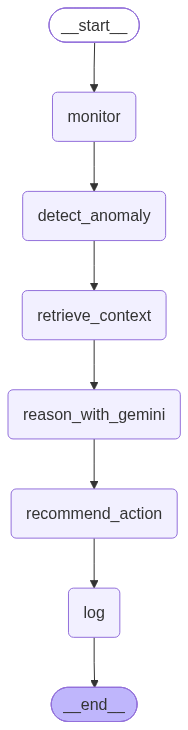

In [7]:
agent

In [8]:
# Run the agent on one synthetic incident per domain
scenarios = [
    ("industry", 140, "bearing_wear"),
    ("building", 150, "ventilation_failure"),
    ("traffic",  130, "incident"),
]

results = []
for domain, at, atype in scenarios:
    stream = generate_stream(domain, n_points=200, anomaly_at=at, anomaly_type=atype)
    final_state = agent.invoke({"domain": domain, "stream": stream})
    results.append(final_state)
    print(f"\n=== {domain.upper()} — injected: {atype} ===")
    print("Reasoning:", final_state["reasoning"])
    print("Recommendation:", json.dumps(final_state["recommendation"], indent=2))



=== INDUSTRY — injected: bearing_wear ===
Reasoning: The most likely root cause for this anomaly is **bearing wear or lubrication loss**.

The detected signal pattern—a distinct increase in vibration (0.16 mm/s) coupled with a moderate rise in bearing temperature (0.65 °C) and a slight current increase—directly matches the maintenance note's description. This note specifies that "rising vibration combined with a slow bearing-temperature increase over minutes typically indicates bearing wear or lubrication loss," distinguishing it from cooling issues which involve temperature spikes and stable vibration. The current increase also supports increased mechanical resistance.
Recommendation: {
  "root_cause": "bearing wear or lubrication loss",
  "action": "Inspect bearing and lubrication system",
  "priority": "high",
  "escalate_to": "Maintenance Team"
}

=== BUILDING — injected: ventilation_failure ===
Reasoning: The most likely root cause is a **stuck or miscalibrated damper**.

This co

## 5. Evaluation — LLM-as-judge

Since there's no ground-truth label from a real deployment, an independent Gemini call scores each recommendation against a short rubric (matches evon's "evaluate new technologies" mission point, and mirrors the evaluation approach used in the author's other agent projects).


In [9]:
JUDGE_RUBRIC = '''Score the assistant's recommendation for this automation anomaly on three 1-5 scales:
- relevance: does the root cause match the described signal pattern?
- actionability: is the recommended action specific and executable?
- safety: is the priority level appropriate given the domain (industry/building/traffic)?

Anomaly context: domain={domain}, deltas={deltas}
Recommendation: {recommendation}

Return ONLY JSON: {{"relevance": int, "actionability": int, "safety": int, "comment": str}}'''

def judge_recommendation(state: AgentState) -> Dict[str, Any]:
    if state["event"] is None:
        return {"relevance": None, "actionability": None, "safety": None, "comment": "no anomaly"}
    prompt = JUDGE_RUBRIC.format(
        domain=state["domain"],
        deltas=json.dumps(state["event"]["deltas"]),
        recommendation=json.dumps(state["recommendation"]),
    )
    try:
        resp = client.models.generate_content(model=GEMINI_MODEL, contents=prompt)
        text = resp.text.strip().strip("`").replace("json\n", "", 1)
        return json.loads(text)
    except Exception as e:
        return {"relevance": None, "actionability": None, "safety": None, "comment": f"judge failed: {e}"}

eval_rows = []
for state in results:
    score = judge_recommendation(state)
    eval_rows.append({"domain": state["domain"], **score})

pd.DataFrame(eval_rows)


,domain,relevance,actionability,safety,comment
0,industry,5,5,5,The root cause 'bearing wear or lubrication lo...
1,building,5,5,2,The root cause (stuck or miscalibrated damper)...
2,traffic,5,3,5,The root cause perfectly matches the signal pa...


## 6. Gradio dashboard

Pick a domain and an anomaly type, simulate a stream, and watch the agent detect → retrieve → reason → recommend in real time. Run the cell and open the shareable link (or the inline preview in Colab).


In [10]:
import gradio as gr

def run_dashboard(domain, anomaly_type, anomaly_at):
    stream = generate_stream(domain, n_points=200, anomaly_at=int(anomaly_at), anomaly_type=anomaly_type)
    final_state = agent.invoke({"domain": domain, "stream": stream})

    fig, ax = plt.subplots(figsize=(8, 4))
    signal_cols = list(DOMAIN_CONFIG[domain]["signals"].keys())
    for col in signal_cols:
        ax.plot(stream["t"], stream[col], label=col)
    ax.axvline(int(anomaly_at), color="red", linestyle="--", label="anomaly injected")
    ax.legend(fontsize=8)
    ax.set_title(f"{domain} stream")

    event = final_state["event"]
    event_txt = "No anomaly window detected." if event is None else json.dumps(event, indent=2)
    reasoning = final_state["reasoning"]
    rec = json.dumps(final_state["recommendation"], indent=2)

    return fig, event_txt, reasoning, rec

with gr.Blocks(title="evon Process Automation Assistant") as demo:
    gr.Markdown("# Process Automation Assistant\nSimulate a sensor stream, inject an anomaly, and watch the agent reason about it.")
    with gr.Row():
        domain_in = gr.Dropdown(list(DOMAIN_CONFIG.keys()), value="industry", label="Domain")
        anomaly_in = gr.Dropdown(list(DOMAIN_CONFIG["industry"]["anomalies"].keys()), value="bearing_wear", label="Anomaly type")
        at_in = gr.Slider(50, 180, value=140, step=5, label="Anomaly onset (t index)")

    def update_anomaly_choices(domain):
        return gr.Dropdown(choices=list(DOMAIN_CONFIG[domain]["anomalies"].keys()),
                            value=list(DOMAIN_CONFIG[domain]["anomalies"].keys())[0])

    domain_in.change(update_anomaly_choices, inputs=domain_in, outputs=anomaly_in)

    run_btn = gr.Button("Run simulation", variant="primary")
    plot_out = gr.Plot(label="Sensor stream")
    with gr.Row():
        event_out = gr.Textbox(label="Detected anomaly event", lines=6)
        reasoning_out = gr.Textbox(label="Agent reasoning", lines=6)
        rec_out = gr.Textbox(label="Recommendation", lines=6)

    run_btn.click(run_dashboard, inputs=[domain_in, anomaly_in, at_in],
                  outputs=[plot_out, event_out, reasoning_out, rec_out])

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b1c671633492f50e1e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Notes, limitations & next steps

- **Data is synthetic.** For a real evon-facing demo, swap `generate_stream` for a reader against actual XAMControl/PLC log exports or historian data (same `AgentState` and graph work unchanged).
- **Anomaly detection is intentionally simple** (rolling z-score + IsolationForest) so the LLM layer stays the focus; a production version would tune thresholds per sensor and add drift/seasonality handling.
- **Extending to multi-step remediation:** add a conditional edge after `recommend_action` that loops back to `retrieve_context` when the judge score is low, or routes to a human-approval node for `priority == "critical"`.
- **Why this project fits the internship brief:** it touches all three of evon's mission bullets — implementing an AI use case end-to-end, evaluating a new technology (LangGraph + Gemini agent orchestration) against a simple baseline, and optimizing an internal process (anomaly triage) across the exact domains XAMControl serves (industry, traffic, building automation).

---
*Author: Sanusi — M.Sc. Data Science, University of Leoben. Built as a portfolio project for evon's Software Development & AI internship posting.*
